# Test Models

This notebook loads trained model checkpoints from `final_models/` and evaluates them on the `test` splits.

Supported models:
- `mlp_baseline` — uses the `LandmarksDataset` with `flatten=True`.
- `cnn_baseline` — uses the `RGBImageDataset`.
- `gnn` — uses the `LandmarksGraphDataset` (PyG graph data).
- `resnet34` — uses the `RGBImageDataset` with larger image size (128x128).
- `fusion` — uses the `FusionDataset` (combined RGB images + graph landmarks).

Metrics reported: Top-1 Accuracy, Macro F1, Macro Precision, Macro Recall, per-class classification report, and confusion matrices.

Results are printed only (not saved). Models are automatically detected from `models_metadata.json`.

In [1]:
import os
import sys
from typing import Dict, Any, Tuple

import torch
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import itertools

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report

# Project root (adjust if needed)
PROJECT_ROOT = os.path.abspath('.')
sys.path.insert(0, PROJECT_ROOT)

# Import model factories and datasets from repo
from model_classes.mlp_baseline import create_mlp_baseline
from model_classes.cnn_baseline import create_cnn_baseline
from model_classes.gnn import create_gnn
from model_classes.resnet import create_resnet34
from model_classes.fusion import create_fusion_model
from data_loaders import LandmarksDataset, RGBImageDataset, LandmarksGraphDataset, FusionDataset, fusion_collate_fn

# PyG for graph data loading
try:
    from torch_geometric.loader import DataLoader as PyGDataLoader
    HAS_PYG = True
except ImportError:
    HAS_PYG = False
    print('Warning: torch_geometric not installed. GNN evaluation will be skipped.')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

/home/quiet98k/Code/Fall25/hand-gestures-classifier/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


In [2]:
# Helper: robustly extract model state dict from saved checkpoint
def extract_state_dict(ckpt: Any) -> dict:
    # ckpt may be a pure state_dict or a wrapper with keys like 'state', 'model_state', 'state_dict'
    if isinstance(ckpt, dict):
        # common patterns
        if 'state' in ckpt and isinstance(ckpt['state'], dict):
            s = ckpt['state']
            if 'model_state' in s:
                return s['model_state']
            if 'state_dict' in s:
                return s['state_dict']
        if 'model_state' in ckpt and isinstance(ckpt['model_state'], dict):
            return ckpt['model_state']
        if 'state_dict' in ckpt and isinstance(ckpt['state_dict'], dict):
            return ckpt['state_dict']
        # Might be full state dict already
        # Heuristic: many values are tensors -> assume this is the state_dict
        # Ensure keys look like parameter names (contain '.')
        if all(isinstance(k, str) and '.' in k for k in ckpt.keys()):
            return ckpt
    raise RuntimeError('Unable to extract model state dict from checkpoint')

# Evaluation routine that collects predictions and computes metrics
def evaluate_model(model: torch.nn.Module, loader, device: torch.device, is_graph: bool = False, is_fusion: bool = False) -> Dict[str, Any]:
    """Evaluate model on loader. Set is_graph=True for PyG graph data, is_fusion=True for fusion data."""
    model = model.to(device).eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch in loader:
            if is_fusion:
                # Fusion batch: dict with 'image', 'graph', 'label'
                images = batch['image'].to(device)
                graph = batch['graph'].to(device)
                y = batch['label']
                logits = model(images, graph.x, graph.edge_index, graph.batch)
            elif is_graph:
                # PyG batch: Data object with .x, .edge_index, .batch, .y
                x = batch.x.to(device)
                edge_index = batch.edge_index.to(device)
                batch_idx = batch.batch.to(device)
                y = batch.y
                logits = model(x, edge_index, batch_idx)
            elif isinstance(batch, dict):
                # Landmark dataset uses key 'landmarks' ; RGB uses 'image'
                if 'landmarks' in batch:
                    x = batch['landmarks'].to(device)
                elif 'image' in batch:
                    x = batch['image'].to(device)
                else:
                    raise RuntimeError('Unknown batch format')
                y = batch['label']
                logits = model(x)
            else:
                x, y = batch
                logits = model(x.to(device))
            preds = logits.argmax(dim=1).cpu().numpy()
            labels = y.cpu().numpy() if isinstance(y, torch.Tensor) else np.array(y)
            all_preds.append(preds)
            all_labels.append(labels)
    if not all_preds:
        return {}
    y_pred = np.concatenate(all_preds, axis=0)
    y_true = np.concatenate(all_labels, axis=0)

    acc = float(accuracy_score(y_true, y_pred))
    f1_macro = float(f1_score(y_true, y_pred, average='macro', zero_division=0))
    prec_macro = float(precision_score(y_true, y_pred, average='macro', zero_division=0))
    rec_macro = float(recall_score(y_true, y_pred, average='macro', zero_division=0))
    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, zero_division=0)

    return {
        'accuracy': acc,
        'f1_macro': f1_macro,
        'precision_macro': prec_macro,
        'recall_macro': rec_macro,
        'confusion_matrix': cm,
        'classification_report': report,
        'y_true': y_true,
        'y_pred': y_pred,
    }

# Small helper to print summary succinctly
def print_summary(name: str, metrics: Dict[str, Any]):
    print('--- {} ---'.format(name))
    print(f"Top-1 Accuracy: {metrics['accuracy']:.4f}")
    print(f"Macro F1: {metrics['f1_macro']:.4f}")
    print(f"Macro Precision: {metrics['precision_macro']:.4f}")
    print(f"Macro Recall: {metrics['recall_macro']:.4f}")
    print('Classification Report:')
    print(metrics['classification_report'])

def plot_confusion_matrix(cm, class_names, ax=None, title='Confusion Matrix'):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.set_title(title)
    tick_marks = np.arange(len(class_names))
    ax.set_xticks(tick_marks)
    ax.set_yticks(tick_marks)
    ax.set_xticklabels(class_names, rotation=90, fontsize=6)
    ax.set_yticklabels(class_names, fontsize=6)
    fmt = 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        ax.text(j, i, format(cm[i, j], fmt),
                horizontalalignment='center',
                color='white' if cm[i, j] > thresh else 'black',
                fontsize=5)
    ax.set_ylabel('True label')
    ax.set_xlabel('Predicted label')
    return ax

In [3]:
# Configuration: build models_to_test from combined metadata when available
final_models_dir = os.path.join(PROJECT_ROOT, 'final_models')
combined_meta_path = os.path.join(final_models_dir, 'models_metadata.json')

from torchvision import transforms as T

models_to_test = []
if os.path.exists(combined_meta_path):
    import json
    with open(combined_meta_path, 'r') as mf:
        try:
            meta = json.load(mf)
        except Exception as e:
            print('Failed to parse models_metadata.json:', e)
            meta = {}
    for name, entry in meta.items():
        ckpt_path = entry.get('checkpoint_path') or os.path.join(final_models_dir, f"{name}.pth")
        data_type = entry.get('data_type', 'rgb')
        batch_size = int(entry.get('training', {}).get('batch_size', 64))
        is_graph = False
        is_fusion = False
        
        if data_type == 'landmarks':
            print(f'Preparing LandmarksDataset (flatten=True) for {name} on test split...')
            ds = LandmarksDataset(annotations_root=os.path.join(PROJECT_ROOT, 'data', 'annotations'), split='test', flatten=True)
            loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
            factory = create_mlp_baseline
        elif data_type in ('graph', 'landmarks_graph'):
            if not HAS_PYG:
                print(f'Skipping {name}: torch_geometric not installed')
                continue
            print(f'Preparing LandmarksGraphDataset for {name} on test split...')
            ds = LandmarksGraphDataset(annotations_root=os.path.join(PROJECT_ROOT, 'data', 'annotations'), split='test')
            loader = PyGDataLoader(ds, batch_size=batch_size, shuffle=False)
            factory = create_gnn
            is_graph = True
        elif data_type == 'fusion':
            if not HAS_PYG:
                print(f'Skipping {name}: torch_geometric not installed')
                continue
            image_size = int(entry.get('image_size', 128))
            print(f'Preparing FusionDataset for {name} on test split (image_size={image_size})...')
            ds = FusionDataset(
                annotations_root=os.path.join(PROJECT_ROOT, 'data', 'annotations'),
                crops_root=os.path.join(PROJECT_ROOT, 'data', 'crops'),
                split='test',
                image_size=image_size
            )
            loader = DataLoader(ds, batch_size=batch_size, shuffle=False, collate_fn=fusion_collate_fn)
            factory = create_fusion_model
            is_fusion = True
        else:
            # RGB data (cnn_baseline, resnet34, etc.)
            image_size = int(entry.get('image_size', 64))
            transform = T.Compose([T.Resize((image_size, image_size))])
            print(f'Preparing RGBImageDataset for {name} on test split (resize={image_size})...')
            ds = RGBImageDataset(crops_root=os.path.join(PROJECT_ROOT, 'data', 'crops'), split='test', transform=transform)
            loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
            model_type = entry.get('model_type', 'cnn_baseline')
            if model_type == 'resnet34':
                factory = create_resnet34
            else:
                factory = create_cnn_baseline
        models_to_test.append((name, factory, ckpt_path, ds, loader, entry, is_graph, is_fusion))
else:
    # Fallback: keep previous hard-coded behavior if metadata file isn't present
    print('models_metadata.json not found in final_models/ — using hardcoded paths/loaders')
    mlp_ckpt_path = os.path.join(final_models_dir, 'mlp_baseline.pth')
    cnn_ckpt_path = os.path.join(final_models_dir, 'cnn_baseline.pth')

    print('Preparing LandmarksDataset (flatten=True) on test split...')
    lm_ds = LandmarksDataset(annotations_root=os.path.join(PROJECT_ROOT, 'data', 'annotations'), split='test', flatten=True)
    lm_loader = DataLoader(lm_ds, batch_size=64, shuffle=False)

    print('Preparing RGBImageDataset on test split...')
    fallback_image_size = 64
    fallback_transform = T.Compose([T.Resize((fallback_image_size, fallback_image_size))])
    rgb_ds = RGBImageDataset(crops_root=os.path.join(PROJECT_ROOT, 'data', 'crops'), split='test', transform=fallback_transform)
    rgb_loader = DataLoader(rgb_ds, batch_size=64, shuffle=False)

    models_to_test = [
        ('mlp_baseline', create_mlp_baseline, mlp_ckpt_path, lm_ds, lm_loader, None, False, False),
        ('cnn_baseline', create_cnn_baseline, cnn_ckpt_path, rgb_ds, rgb_loader, None, False, False),
    ]

print('Models to test:', [m[0] for m in models_to_test])

Preparing LandmarksDataset (flatten=True) for mlp_baseline on test split...
Preparing RGBImageDataset for cnn_baseline on test split (resize=64)...
Preparing RGBImageDataset for cnn_baseline on test split (resize=64)...
Preparing LandmarksGraphDataset for gnn on test split...
Preparing LandmarksGraphDataset for gnn on test split...
Preparing RGBImageDataset for resnet34 on test split (resize=128)...
Preparing FusionDataset for fusion on test split (image_size=128)...
Preparing RGBImageDataset for resnet34 on test split (resize=128)...
Preparing FusionDataset for fusion on test split (image_size=128)...
Models to test: ['mlp_baseline', 'cnn_baseline', 'gnn', 'resnet34', 'fusion']
Models to test: ['mlp_baseline', 'cnn_baseline', 'gnn', 'resnet34', 'fusion']


In [4]:
# Run evaluations for the configured models and collect results
results = {}
for name, factory, ckpt_path, ds, loader, meta_entry, is_graph, is_fusion in models_to_test:
    print(f'\nEvaluating {name}...')
    if not os.path.exists(ckpt_path):
        print(f'Checkpoint not found: {ckpt_path} -- skipping {name}')
        continue

    # Instantiate model using metadata when available (more robust)
    try:
        if meta_entry:
            mtype = meta_entry.get('model_type')
            if mtype == 'mlp_baseline':
                model = create_mlp_baseline(
                    input_dim=int(meta_entry['input_dim']),
                    num_classes=int(meta_entry['num_classes']),
                    hidden_dims=tuple(meta_entry.get('hidden_dims', [])),
                    dropout=float(meta_entry.get('dropout', 0.0)),
                    activation=meta_entry.get('activation', 'relu'),
                    batchnorm=bool(meta_entry.get('batchnorm', False)),
                )
            elif mtype == 'cnn_baseline':
                model = create_cnn_baseline(
                    input_channels=int(meta_entry.get('input_channels', 3)),
                    num_classes=int(meta_entry['num_classes']),
                    conv_channels=tuple(meta_entry.get('conv_channels', [])),
                    kernel_size=int(meta_entry.get('kernel_size', 3)),
                    pool_every=int(meta_entry.get('pool_every', 2)),
                    dropout=float(meta_entry.get('dropout', 0.0)),
                    activation=meta_entry.get('activation', 'relu'),
                    batchnorm=bool(meta_entry.get('batchnorm', False)),
                )
            elif mtype == 'gnn':
                model = create_gnn(
                    in_channels=int(meta_entry.get('in_channels', 2)),
                    num_classes=int(meta_entry['num_classes']),
                    hidden_channels=int(meta_entry.get('hidden_channels', 64)),
                    num_layers=int(meta_entry.get('num_layers', 3)),
                    dropout=float(meta_entry.get('dropout', 0.0)),
                    activation=meta_entry.get('activation', 'relu'),
                    mlp_hidden=meta_entry.get('mlp_hidden'),
                )
            elif mtype == 'resnet34':
                model = create_resnet34(
                    input_channels=int(meta_entry.get('input_channels', 3)),
                    num_classes=int(meta_entry['num_classes']),
                    dropout=float(meta_entry.get('dropout', 0.0)),
                    pretrained_backbone=False,  # don't load pretrained weights, we'll load checkpoint
                )
            elif mtype == 'fusion':
                model = create_fusion_model(
                    num_classes=int(meta_entry['num_classes']),
                    gnn_hidden_channels=int(meta_entry.get('gnn_hidden_channels', 64)),
                    gnn_num_layers=int(meta_entry.get('gnn_num_layers', 3)),
                    gnn_dropout=float(meta_entry.get('gnn_dropout', 0.0)),
                    resnet_dropout=float(meta_entry.get('resnet_dropout', 0.0)),
                    resnet_pretrained=False,  # don't load pretrained, we have checkpoint
                    fusion_hidden=int(meta_entry.get('fusion_hidden', 256)),
                    fusion_dropout=float(meta_entry.get('fusion_dropout', 0.0)),
                )
            else:
                raise RuntimeError(f'Unknown model_type in metadata: {mtype}')
        else:
            # fallback to previous heuristics
            if name.startswith('mlp'):
                sample = ds[0]['landmarks']
                input_dim = int(sample.numel()) if hasattr(sample, 'numel') else int(np.prod(sample.shape))
                model = factory(input_dim=input_dim, num_classes=ds.num_classes)
            elif is_graph:
                model = factory(in_channels=2, num_classes=ds.num_classes)
            else:
                # try to infer input channels from a sample
                sample = ds[0]['image'] if isinstance(ds[0], dict) else ds[0][0]
                input_channels = int(sample.size(0)) if hasattr(sample, 'size') else 3
                model = factory(input_channels=input_channels, num_classes=ds.num_classes)
        model = model.to('cpu')
    except Exception as e:
        print('Failed to instantiate model for', name, '->', e)
        continue

    # Load checkpoint (robustly)
    try:
        ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
        try:
            state = extract_state_dict(ckpt)
        except RuntimeError:
            # maybe checkpoint was a plain state dict saved directly
            if isinstance(ckpt, dict) and all(isinstance(k, str) and '.' in k for k in ckpt.keys()):
                state = ckpt
            else:
                raise
        model.load_state_dict(state)
    except Exception as e:
        print('Failed to load checkpoint for', name, '->', e)
        continue

    # Evaluate
    try:
        metrics = evaluate_model(model, loader, device, is_graph=is_graph, is_fusion=is_fusion)
        if not metrics:
            print('No predictions for', name)
            continue
        # Attempt to get class names from dataset
        try:
            class_names = ds.class_names()
        except Exception:
            # fallback: generate range
            class_names = [str(i) for i in range(meta_entry.get('num_classes', getattr(ds, 'num_classes', 0)))] if meta_entry else [str(i) for i in range(getattr(ds, 'num_classes', 0))]

        results[name] = { 'metrics': metrics, 'class_names': class_names }
        print(f'Done evaluating {name}')
    except Exception as e:
        print('Evaluation failed for', name, '->', e)

# If no results found notify user
if not results:
    print('No model results available. Check that checkpoint files exist in final_models/ and datasets are available under data/.')


Evaluating mlp_baseline...
Done evaluating mlp_baseline

Evaluating cnn_baseline...
Done evaluating mlp_baseline

Evaluating cnn_baseline...
Done evaluating cnn_baseline

Evaluating gnn...
Done evaluating cnn_baseline

Evaluating gnn...
Done evaluating gnn

Evaluating resnet34...
Done evaluating gnn

Evaluating resnet34...
Done evaluating resnet34

Evaluating fusion...
Done evaluating resnet34

Evaluating fusion...
Done evaluating fusion
Done evaluating fusion


=== Summary Table ===
Model        | Top-1 Accuracy | Macro F1 | Macro Precision | Macro Recall
-------------+----------------+----------+-----------------+-------------
mlp_baseline | 0.9876         | 0.9876   | 0.9876          | 0.9876      
cnn_baseline | 0.5295         | 0.5160   | 0.5257          | 0.5295      
gnn          | 0.9779         | 0.9779   | 0.9781          | 0.9779      
resnet34     | 0.9970         | 0.9970   | 0.9970          | 0.9970      
fusion       | 0.9972         | 0.9972   | 0.9972          | 0.9972      

Results for: mlp_baseline
--- mlp_baseline ---
Top-1 Accuracy: 0.9876
Macro F1: 0.9876
Macro Precision: 0.9876
Macro Recall: 0.9876
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4936
           1       0.99      1.00      1.00      4932
           2       1.00      1.00      1.00      4877
           3       0.99      1.00      0.99      4969
           4       0.99      1.00

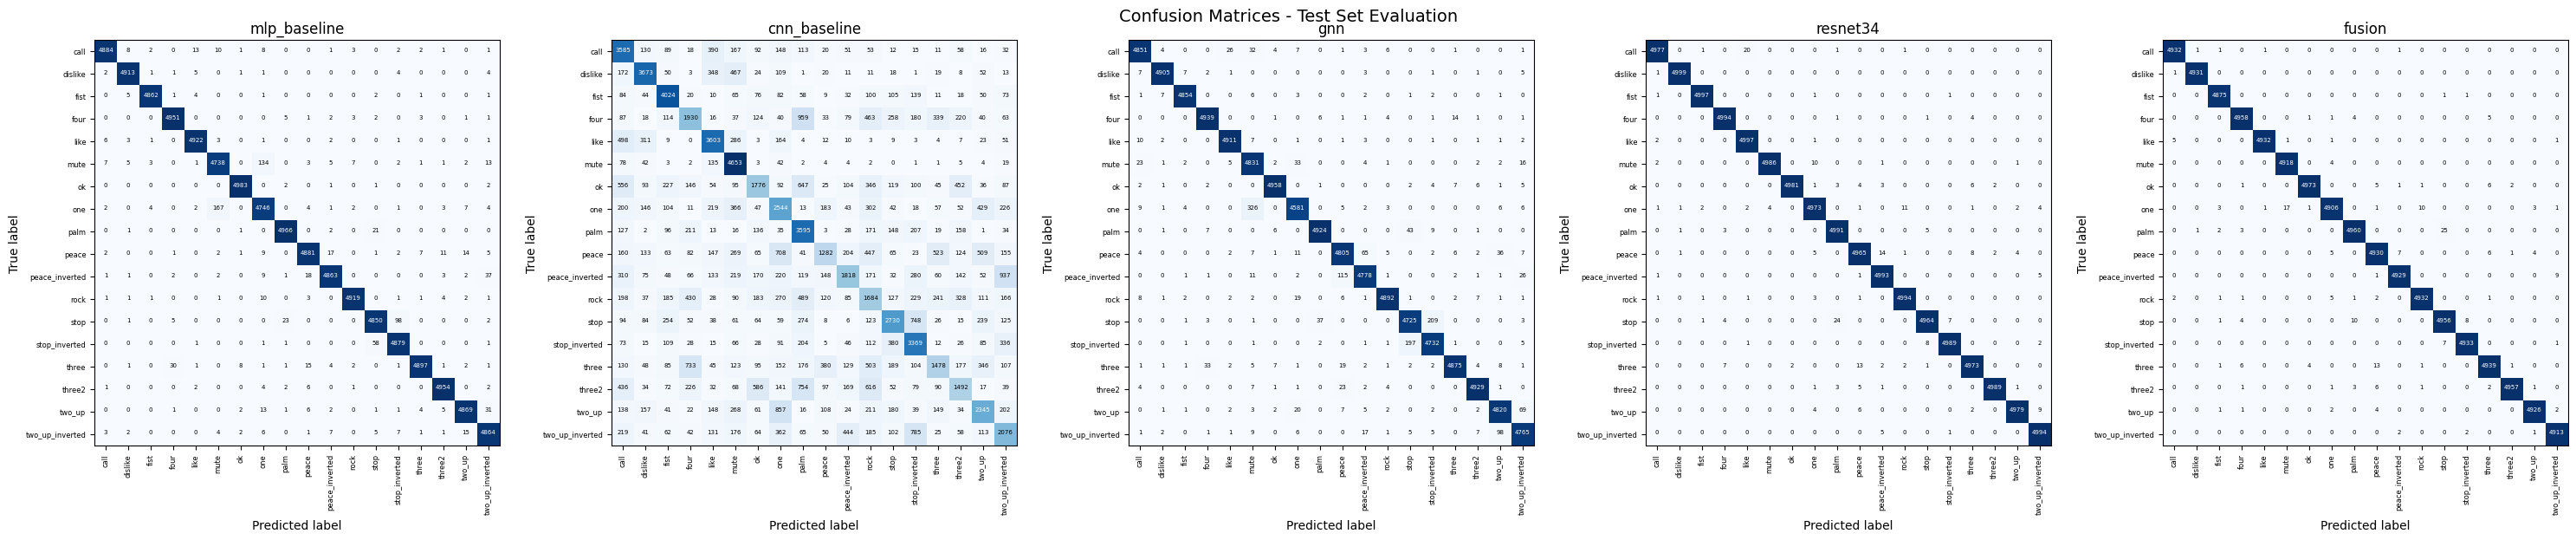

Saved confusion matrices to /home/quiet98k/Code/Fall25/hand-gestures-classifier/graphs/confusion_matrices.png


In [5]:
# Print summaries side-by-side for quick comparison
if results:
    # Ensure graphs directory exists
    graphs_dir = os.path.join(PROJECT_ROOT, 'graphs')
    os.makedirs(graphs_dir, exist_ok=True)
    
    # Print a compact table of core metrics
    names = list(results.keys())
    print('=== Summary Table ===')
    header = ['Model', 'Top-1 Accuracy', 'Macro F1', 'Macro Precision', 'Macro Recall']
    rows = []
    for n in names:
        m = results[n]['metrics']
        rows.append([n, f"{m['accuracy']:.4f}", f"{m['f1_macro']:.4f}", f"{m['precision_macro']:.4f}", f"{m['recall_macro']:.4f}"])
    
    # Calculate column widths for alignment
    all_rows = [header] + rows
    col_widths = [max(len(row[i]) for row in all_rows) for i in range(len(header))]
    
    # Print aligned table
    def format_row(row):
        return ' | '.join(val.ljust(col_widths[i]) for i, val in enumerate(row))
    
    print(format_row(header))
    print('-+-'.join('-' * w for w in col_widths))
    for r in rows:
        print(format_row(r))

    # Print full classification reports side-by-side (one after another)
    for n in names:
        print('\n' + '='*40)
        print(f'Results for: {n}')
        print_summary(n, results[n]['metrics'])

    # Plot confusion matrices side-by-side
    num = len(names)
    fig, axes = plt.subplots(1, num, figsize=(6 * num, 6))
    fig.suptitle('Confusion Matrices - Test Set Evaluation', fontsize=14)
    if num == 1:
        axes = [axes]
    for ax, n in zip(axes, names):
        cm = results[n]['metrics']['confusion_matrix']
        classes = results[n]['class_names']
        plot_confusion_matrix(cm, classes, ax=ax, title=n)
    plt.tight_layout()
    plt.savefig(os.path.join(graphs_dir, 'confusion_matrices.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved confusion matrices to {graphs_dir}/confusion_matrices.png')
else:
    print('No results to display.')